In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA


pd.set_option('display.max_columns', None)
sns.set(style="whitegrid", palette="pastel")

df = pd.read_csv("/home/onyxia/work/ml-uncertainty-quantification-and-sources/bank-full.csv", sep=';')

Échantillonnage stratifié : C’est un concept important souvent manqué lors du développement d’un modèle, que ce soit pour la régression ou la classification. Rappelez-vous que, pour éviter le surapprentissage de nos données, nous devons mettre en place une validation croisée, cependant, nous devons nous assurer qu’au moins les fonctionnalités ayant le plus d’influence sur notre étiquette (qu’un client potentiel ouvre un dépôt à terme ou non) soient réparties équitablement. Que veux-je dire par là ?

1) Nous devons voir comment nos données sont distribuées.
2) Après avoir noté que la colonne « prêt » contient 87 % de « non » (Ne pas de prêts personnels) et 13 % de « oui » (Avoir des prêts personnels).
3) Nous voulons nous assurer que notre ensemble d’entraînement et de test contient le même ratio de 87 % de « non » et 13 % de « oui ». Échantillonnage stratifié : C’est un concept important souvent manqué lors du développement d’un modèle, que ce soit pour la régression ou la classification.

Afin de préserver la distribution déséquilibrée de la variable cible, les données ont été séparées en ensembles d’apprentissage et de test à l’aide d’un échantillonnage stratifié basé sur la variable de souscription. Cette approche garantit une représentativité cohérente des classes dans les deux ensembles.

In [21]:
# Echantillonage train-set 

from sklearn.model_selection import StratifiedShuffleSplit

# Définition du split stratifié sur la variable cible
stratified = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

# Split
for train_idx, test_idx in stratified.split(df, df["y"]):
    stratified_train = df.loc[train_idx]
    stratified_test = df.loc[test_idx]

# Vérification des distributions
print("Distribution globale :")
print(df["y"].value_counts(normalize=True))

print("\nDistribution train :")
print(stratified_train["y"].value_counts(normalize=True))

print("\nDistribution test :")
print(stratified_test["y"].value_counts(normalize=True))


Distribution globale :
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

Distribution train :
y
no     0.883018
yes    0.116982
Name: proportion, dtype: float64

Distribution test :
y
no     0.883003
yes    0.116997
Name: proportion, dtype: float64


In [22]:
# Encodage des variables
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer


categorical_nominal = [
    "job", "marital", "education",
    "contact", "month", "poutcome"
]

categorical_binary = ["default", "housing", "loan"]

numerical_features = [
    "age", "balance", "day",
    "campaign", "pdays", "previous",
]

#making preprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat_nom", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_nominal),
        ("cat_bin", OneHotEncoder(drop="if_binary"), categorical_binary)
    ]
)


In [23]:
# Séparation X / y
X_train = stratified_train.drop(columns=["y"])
X_test  = stratified_test.drop(columns=["y"])

# Encoder y
le = LabelEncoder()
y_train = le.fit_transform(stratified_train["y"])
y_test  = le.transform(stratified_test["y"])

# Préprocessing
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)



Suite : Maxime

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_transformed, y_train)

y_proba = model.predict_proba(X_test_transformed)[:, 1] #Proba de succès
y_proba[:10]


array([0.01325112, 0.02553587, 0.03577086, 0.01729086, 0.13129165,
       0.04834753, 0.07100212, 0.83871235, 0.11114706, 0.09541112])

In [25]:
def predict_with_threshold(proba, threshold):
    return (proba >= threshold).astype(int) #Renvoie 0 ou 1 selon que la proba dépasse le seuil en argument

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds_logistic = np.linspace(0.05, 0.95, 50) #On va tester 90 seuils pour voir celui qui nous semble le plus pertinent

#Voici les métrics qu'on va regarder
precision_list_logistic = [] 
recall_list_logistic = []
f1_list_logistic = []
accuracy_list_logistic = []

for t in thresholds_logistic:
    y_pred_t = (y_proba >= t).astype(int) #A chaque étape on regénère un array de 0/1 selon le threshold
    
    precision_list_logistic.append(precision_score(y_test, y_pred_t))
    recall_list_logistic.append(recall_score(y_test, y_pred_t))
    f1_list_logistic.append(f1_score(y_test, y_pred_t,pos_label=1))
    accuracy_list_logistic.append(accuracy_score(y_test, y_pred_t))

best_idx_logistic = np.argmax(f1_list_logistic)
best_threshold_logistic = thresholds_logistic[best_idx_logistic]


/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


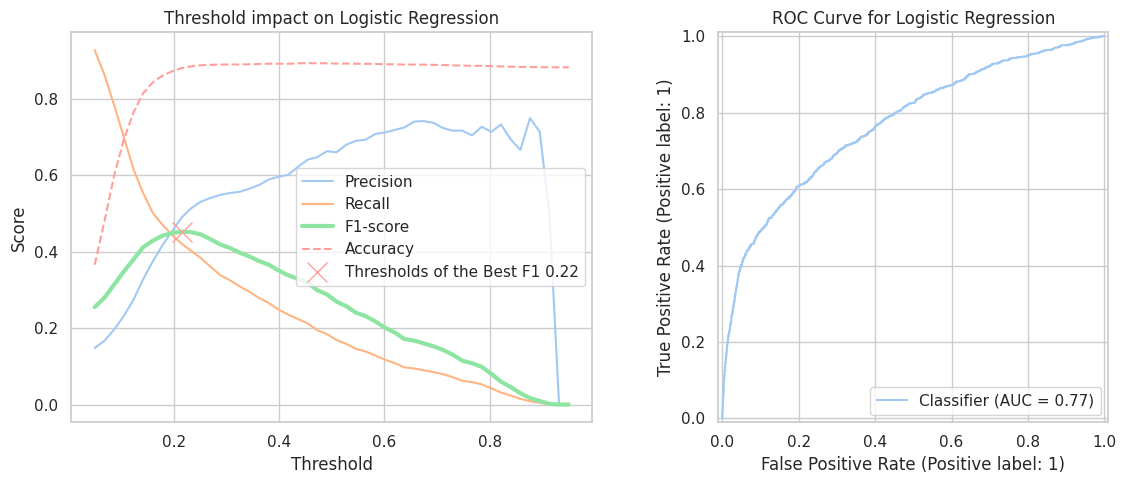

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Premier graphique (à gauche)
axes[0].plot(thresholds_logistic, precision_list_logistic, label="Precision")
axes[0].plot(thresholds_logistic, recall_list_logistic, label="Recall")
axes[0].plot(thresholds_logistic, f1_list_logistic, label="F1-score", linewidth=3)
axes[0].plot(thresholds_logistic, accuracy_list_logistic, label="Accuracy", linestyle="--")
axes[0].plot(thresholds_logistic[best_idx_logistic], f1_list_logistic[best_idx_logistic], 
             'rx', markersize=15, markeredgewidth=1, label=f"Thresholds of the Best F1 {thresholds_logistic[best_idx_logistic]:.2f}")

axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Threshold impact on Logistic Regression")
axes[0].legend()
axes[0].grid(True)

# Deuxième graphique (à droite)
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("ROC Curve for Logistic Regression")

plt.tight_layout()
plt.show()


In [28]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Split train en proper_train et calibration : D'abord on entraîne le modèle sur une partie des données, ensuite on calibre nos quantile sur l'échantillon calib
X_train_fit, X_calib, y_train_fit, y_calib = train_test_split(
    X_train_transformed, y_train, test_size=0.2, random_state=42, stratify=y_train
) #En gros : on séparer en 2 notre train, à l'aide de la fonction train_tes_split, on veut encore une fois garder les mêmes proportions de classes dans chaque échantillon

# 2. Entraîner le modèle
model = LogisticRegression(max_iter=1000) #Ici on 'nomme notre modèle'
model.fit(X_train_fit, y_train_fit) #On l'applique ici au 1er (sur les 3 échantillons)

#IMPORTANT :::  3. Calculer les scores de non-conformité sur le set de calibration
# y_calib_proba nous donne une matrice 2xn, avec pour chaque ligne la proba pour chaque classe
# Puisque le score c'est 1-proba prédite pour la vraie classe
# On extrait de y_calib_proba, chaque ligne (à l'aide de np.arange) et dans chaque ligne, on prend
# la vraie classe : astuce : vraie classe = 1, or, l'index de la proba prédite ( dans une ligne ) que ça soit la classe 1, est 1.

y_calib_proba = model.predict_proba(X_calib) 
calib_scores = 1 - y_calib_proba[np.arange(len(y_calib)), y_calib]
#On obtient donc un vecteur avec tous les scores

# 4. Calculer le quantile pour le niveau de confiance souhaité
alpha = 0.05  # 95% de confiance
n_calib = len(calib_scores)
q_level = np.ceil((n_calib + 1) * (1 - alpha)) / n_calib
quantile = np.quantile(calib_scores, q_level)

print(f"Quantile pour alpha={alpha} : {quantile:.4f}")

# 5. Prédire sur le test set avec prediction sets
y_test_proba = model.predict_proba(X_test_transformed)
y_test_scores = 1 - y_test_proba

# Créer les prediction sets
prediction_sets = y_test_scores <= quantile

# Compter chaque type d'ensemble
set_0_only = np.sum((prediction_sets[:, 0] == True) & (prediction_sets[:, 1] == False))
set_1_only = np.sum((prediction_sets[:, 0] == False) & (prediction_sets[:, 1] == True))
set_both = np.sum((prediction_sets[:, 0] == True) & (prediction_sets[:, 1] == True))
set_empty = np.sum((prediction_sets[:, 0] == False) & (prediction_sets[:, 1] == False))

total = len(prediction_sets)

tableau = pd.DataFrame({
    'Ensemble': ['{0}', '{1}', '{0, 1}', '∅ (vide)'],
    'Nombre': [set_0_only, set_1_only, set_both, set_empty],
    'Pourcentage (%)': [
        (set_0_only / total * 100),
        (set_1_only / total * 100),
        (set_both / total * 100),
        (set_empty / total * 100)
    ]
})

tableau['Pourcentage (%)'] = tableau['Pourcentage (%)'].round(2)

print("\n" + "="*60)
print("DISTRIBUTION DES PREDICTION SETS")
print("="*60)
print(tableau.to_string(index=False))
print("="*60)
print(f"\nTotal : {total} exemples")

Quantile pour alpha=0.05 : 0.8649

DISTRIBUTION DES PREDICTION SETS
Ensemble  Nombre  Pourcentage (%)
     {0}    7063            78.10
     {1}      16             0.18
  {0, 1}    1964            21.72
∅ (vide)       0             0.00

Total : 9043 exemples


Je pense qu'on peut choisir ~2000 comme première baseline du nomnbre de {0,1} qu'on veut. On va essayer d'affiner notre modèle de logistic regression en retirant certaines variables qui ajoutent du bruit.

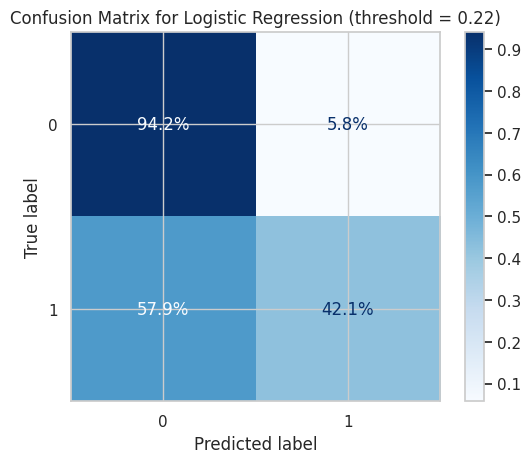

In [29]:
y_pred_logistic = (y_proba >= thresholds_logistic[best_idx_logistic]).astype(int)

# Créer et afficher la matrice de confusion avec pourcentages
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_logistic,
    normalize='true',  # 'true' pour pourcentages par ligne, 'all' pour total
    cmap='Blues',
    values_format='.1%'  # Format pourcentage avec 1 décimale
)
plt.title(f"Confusion Matrix for Logistic Regression (threshold = {thresholds_logistic[best_idx_logistic]:.2f})")
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Split train en proper_train et calibration : En gros, on entrâine le modèle, et ensuite on le calibre
X_train_fit, X_calib, y_train_fit, y_calib = train_test_split(
    X_train_transformed, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# 2. Entraîner le modèle
model = LogisticRegression(max_iter=1000)
model.fit(X_train_fit, y_train_fit)

# 3. Calculer les scores de non-conformité sur le set de calibration
y_calib_proba = model.predict_proba(X_calib)
calib_scores = 1 - y_calib_proba[np.arange(len(y_calib)), y_calib]

# 4. Calculer le quantile pour le niveau de confiance souhaité
alpha = 0.1  # 90% de confiance
n_calib = len(calib_scores)
q_level = np.ceil((n_calib + 1) * (1 - alpha)) / n_calib
quantile = np.quantile(calib_scores, q_level)

print(f"Quantile pour alpha={alpha} : {quantile:.4f}")

# 5. Prédire sur le test set avec prediction sets
y_test_proba = model.predict_proba(X_test_transformed)
y_test_scores = 1 - y_test_proba

# Créer les prediction sets
prediction_sets = y_test_scores <= quantile
set_sizes = np.sum(prediction_sets, axis=1)
unique, counts = np.unique(set_sizes, return_counts=True)

tableau = pd.DataFrame({
    'Taille du set': unique,
    'Nombre': counts,
    'Pourcentage (%)': (counts / len(set_sizes) * 100).round(2)
})

print(tableau)

Quantile pour alpha=0.1 : 0.5510
   Taille du set  Nombre  Pourcentage (%)
0              1    8921            98.65
1              2     122             1.35


In [31]:
# Compter chaque type d'ensemble
set_0_only = np.sum((prediction_sets[:, 0] == True) & (prediction_sets[:, 1] == False))
set_1_only = np.sum((prediction_sets[:, 0] == False) & (prediction_sets[:, 1] == True))
set_both = np.sum((prediction_sets[:, 0] == True) & (prediction_sets[:, 1] == True))
set_empty = np.sum((prediction_sets[:, 0] == False) & (prediction_sets[:, 1] == False))

total = len(prediction_sets)

tableau = pd.DataFrame({
    'Ensemble': ['{0}', '{1}', '{0, 1}', '∅ (vide)'],
    'Nombre': [set_0_only, set_1_only, set_both, set_empty],
    'Pourcentage (%)': [
        (set_0_only / total * 100),
        (set_1_only / total * 100),
        (set_both / total * 100),
        (set_empty / total * 100)
    ]
})

tableau['Pourcentage (%)'] = tableau['Pourcentage (%)'].round(2)

print("\n" + "="*60)
print("DISTRIBUTION DES PREDICTION SETS")
print("="*60)
print(tableau.to_string(index=False))
print("="*60)
print(f"\nTotal : {total} exemples")


DISTRIBUTION DES PREDICTION SETS
Ensemble  Nombre  Pourcentage (%)
     {0}    8699            96.20
     {1}     222             2.45
  {0, 1}     122             1.35
∅ (vide)       0             0.00

Total : 9043 exemples


On va essayer de mettre en place une méthode LDA

In [32]:
lda = LDA(store_covariance=True)
lda.fit(X_train_transformed.toarray(), y_train) #On passe au array pour éviter une matrice sparsed
results=lda.predict(X_test_transformed.toarray()) 
results_probas=lda.predict_proba(X_test_transformed.toarray())[:,1] #Application du LDA pour obtenir les probas

thresholds_LDA = np.linspace(0.05, 0.95, 50) #On va tester 90 seuils pour voir celui qui nous semble le plus pertinent

#Voici les métrics qu'on va regarder
precision_list_LDA = [] 
recall_list_LDA = []
f1_list_LDA = []
accuracy_list_LDA = []

for t in thresholds_LDA:
    results_pred_t = (results_probas >= t).astype(int) #A chaque étape on regénère un array de 0/1 selon le threshold
    
    precision_list_LDA.append(precision_score(y_test, results_pred_t))
    recall_list_LDA.append(recall_score(y_test, results_pred_t))
    f1_list_LDA.append(f1_score(y_test, results_pred_t))
    accuracy_list_LDA.append(accuracy_score(y_test, results_pred_t));

best_idx_LDA = np.argmax(f1_list_LDA)
best_threshold_LDA = thresholds_LDA[best_idx_LDA]

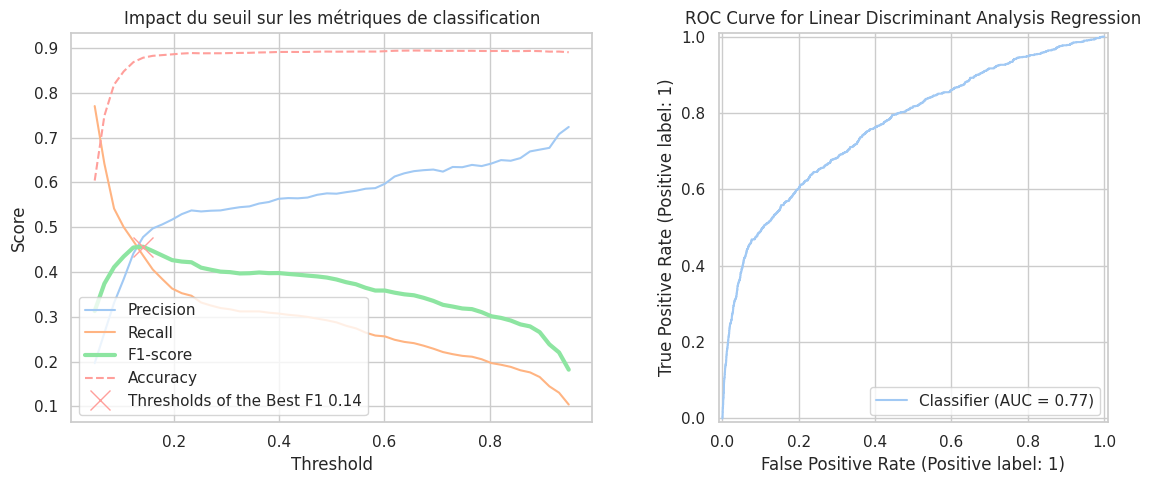

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(thresholds_LDA, precision_list_LDA, label="Precision")
axes[0].plot(thresholds_LDA, recall_list_LDA, label="Recall")
axes[0].plot(thresholds_LDA, f1_list_LDA, label="F1-score", linewidth=3)
axes[0].plot(thresholds_LDA, accuracy_list_LDA, label="Accuracy", linestyle="--")
axes[0].plot(thresholds_LDA[best_idx_LDA], f1_list_LDA[best_idx_LDA], 
             'rx', markersize=15, markeredgewidth=1, label=f"Thresholds of the Best F1 {thresholds_LDA[best_idx_LDA]:.2f}")

axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Impact du seuil sur les métriques de classification")
axes[0].legend()
axes[0].grid(True)

RocCurveDisplay.from_predictions(y_test, results_probas, ax=axes[1])
axes[1].set_title("ROC Curve for Linear Discriminant Analysis Regression")

plt.tight_layout()
plt.show()

On laisse de l'espace pour étudier plus tard quels features sont les plus intéressants.

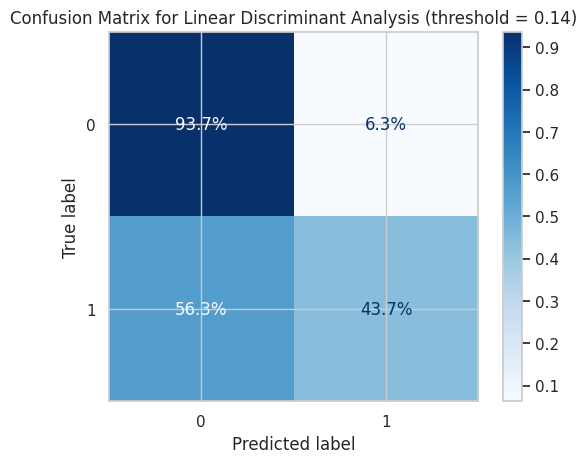

In [34]:
y_pred_LDA = (results_probas >= thresholds_LDA[best_idx_LDA]).astype(int)

# Créer et afficher la matrice de confusion avec pourcentages
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_LDA,
    normalize='true',  # 'true' pour pourcentages par ligne, 'all' pour total
    cmap='Blues',
    values_format='.1%'  # Format pourcentage avec 1 décimale
)
plt.title(f"Confusion Matrix for Linear Discriminant Analysis (threshold = {thresholds_LDA[best_idx_LDA]:.2f})")
plt.show()


QDA

In [35]:
qda = QDA(store_covariance=True)
qda.fit(X_train_transformed.toarray(), y_train) #On passe au array pour éviter une matrice sparsed

,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",True
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


On va essayer de mettre en place une méthode LDA

In [36]:
results_QDA=qda.predict(X_test_transformed.toarray())
results_probas_QDA=qda.predict_proba(X_test_transformed.toarray())[:,1]

thresholds_QDA = np.linspace(0.05, 0.95, 50) #On va tester 90 seuils pour voir celui qui nous semble le plus pertinent

#Voici les métrics qu'on va regarder
precision_list_QDA = [] 
recall_list_QDA = []
f1_list_QDA = []
accuracy_list_QDA = []

for t in thresholds_QDA:
    results_pred_t = (results_probas_QDA >= t).astype(int) #A chaque étape on regénère un array de 0/1 selon le threshold
    
    precision_list_QDA.append(precision_score(y_test, results_pred_t))
    recall_list_QDA.append(recall_score(y_test, results_pred_t))
    f1_list_QDA.append(f1_score(y_test, results_pred_t))
    accuracy_list_QDA.append(accuracy_score(y_test, results_pred_t));

best_idx_QDA = np.argmax(f1_list_QDA)
best_threshold_QDA = thresholds_QDA[best_idx_QDA]

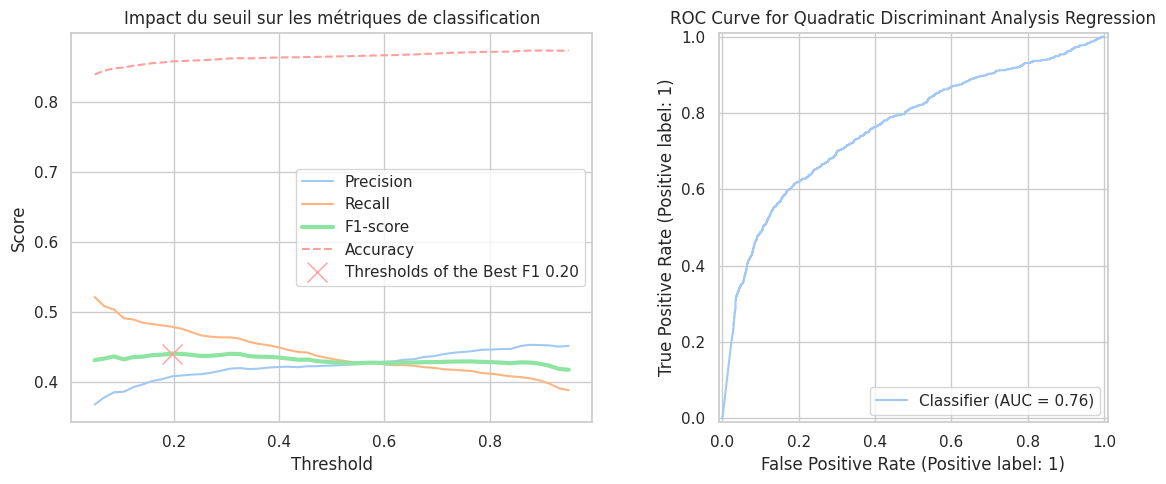

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(thresholds_QDA, precision_list_QDA, label="Precision")
axes[0].plot(thresholds_QDA, recall_list_QDA, label="Recall")
axes[0].plot(thresholds_QDA, f1_list_QDA, label="F1-score", linewidth=3)
axes[0].plot(thresholds_QDA, accuracy_list_QDA, label="Accuracy", linestyle="--")
axes[0].plot(thresholds_QDA[best_idx_QDA], f1_list_QDA[best_idx_QDA], 
             'rx', markersize=15, markeredgewidth=1, label=f"Thresholds of the Best F1 {thresholds_QDA[best_idx_QDA]:.2f}")

axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Impact du seuil sur les métriques de classification")
axes[0].legend()
axes[0].grid(True)

RocCurveDisplay.from_predictions(y_test, results_probas_QDA, ax=axes[1])
axes[1].set_title("ROC Curve for Quadratic Discriminant Analysis Regression")

plt.tight_layout()
plt.show()

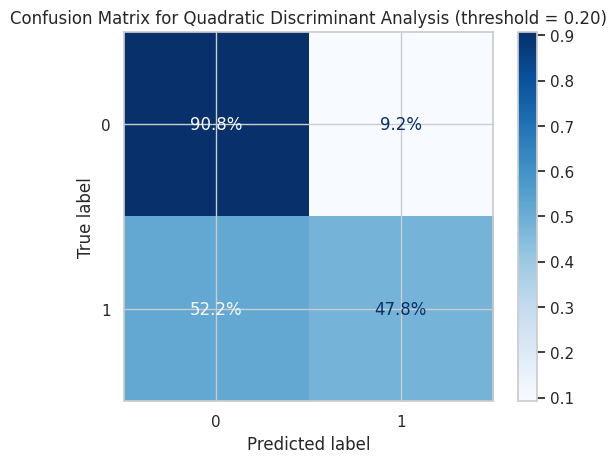

In [38]:
y_pred_QDA  = (results_probas_QDA >= thresholds_QDA[best_idx_QDA]).astype(int)

# Créer et afficher la matrice de confusion avec pourcentages
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_QDA,
    normalize='true',  # 'true' pour pourcentages par ligne, 'all' pour total
    cmap='Blues',
    values_format='.1%'  # Format pourcentage avec 1 décimale
)
plt.title(f"Confusion Matrix for Quadratic Discriminant Analysis (threshold = {thresholds_QDA[best_idx_QDA]:.2f})")
plt.show()

Essayons d'appliquer une conformal prediction maintenant :

In [57]:
from sklearn.preprocessing import StandardScaler

# Séparation X / y
X_train = stratified_train.drop(columns=["y"])
X_test  = stratified_test.drop(columns=["y"])

# Encoder y
le = LabelEncoder()
y_train = le.fit_transform(stratified_train["y"])
y_test  = le.transform(stratified_test["y"])

# Préprocessing
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

# Normalisation pour matrices sparse
scaler = StandardScaler(with_mean=False)  # <-- Important !
X_train_normalized = scaler.fit_transform(X_train_transformed)
X_test_normalized = scaler.transform(X_test_transformed)

# Régression logistique L1
from sklearn.linear_model import LogisticRegression

model_l1 = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.01,           # <-- hyperparamètre clé
    max_iter=5000
)

model_l1.fit(X_train_normalized, y_train)

/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass

In [58]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

y_proba = model.predict_proba(X_test_normalized)[:, 1] #Proba de succès
thresholds_logistic_L1 = np.linspace(0.05, 0.95, 50) #On va tester 90 seuils pour voir celui qui nous semble le plus pertinent

#Voici les métrics qu'on va regarder
precision_list_logistic = [] 
recall_list_logistic = []
f1_list_logistic = []
accuracy_list_logistic = []

for t in thresholds_logistic:
    y_pred_t = (y_proba >= t).astype(int) #A chaque étape on regénère un array de 0/1 selon le threshold
    
    precision_list_logistic.append(precision_score(y_test, y_pred_t))
    recall_list_logistic.append(recall_score(y_test, y_pred_t))
    f1_list_logistic.append(f1_score(y_test, y_pred_t,pos_label=1))
    accuracy_list_logistic.append(accuracy_score(y_test, y_pred_t))

best_idx_logistic_L1 = np.argmax(f1_list_logistic)
best_threshold_logistic_L1 = thresholds_logistic[best_idx_logistic_L1]


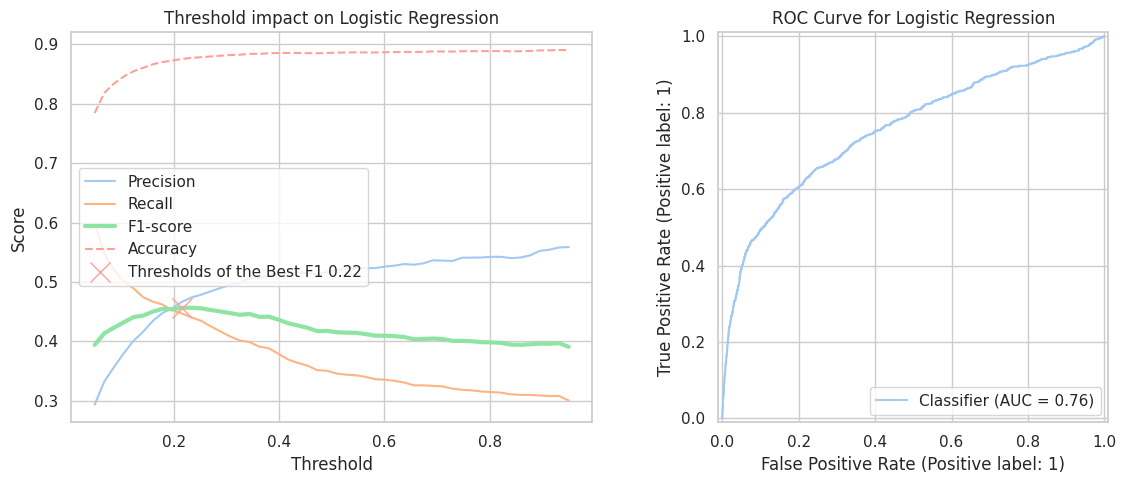

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Premier graphique (à gauche)
axes[0].plot(thresholds_logistic, precision_list_logistic, label="Precision")
axes[0].plot(thresholds_logistic, recall_list_logistic, label="Recall")
axes[0].plot(thresholds_logistic, f1_list_logistic, label="F1-score", linewidth=3)
axes[0].plot(thresholds_logistic, accuracy_list_logistic, label="Accuracy", linestyle="--")
axes[0].plot(thresholds_logistic[best_idx_logistic], f1_list_logistic[best_idx_logistic], 
             'rx', markersize=15, markeredgewidth=1, label=f"Thresholds of the Best F1 {thresholds_logistic[best_idx_logistic]:.2f}")

axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Threshold impact on Logistic Regression")
axes[0].legend()
axes[0].grid(True)

# Deuxième graphique (à droite)
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("ROC Curve for Logistic Regression")

plt.tight_layout()
plt.show()


In [60]:
# Récupérer features et coefficients
feature_names = preprocessor.get_feature_names_out()
coefficients = model_l1.coef_[0]

# Features non nulles
mask_non_zero = coefficients != 0
selected_features = feature_names[mask_non_zero]
selected_coefs = coefficients[mask_non_zero]

print(f"Features sélectionnées ({len(selected_features)}/{len(feature_names)}) :")
for feat, coef in sorted(zip(selected_features, selected_coefs), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:40s} : {coef:+.4f}")

Features sélectionnées (26/41) :
  cat_nom__contact_unknown                 : -0.4908
  cat_nom__poutcome_success                : +0.3538
  cat_bin__housing_yes                     : -0.2827
  cat_nom__month_aug                       : -0.2430
  cat_nom__month_jul                       : -0.2049
  cat_nom__month_may                       : -0.2031
  cat_nom__month_nov                       : -0.1996
  num__campaign                            : -0.1764
  cat_nom__marital_married                 : -0.1608
  cat_nom__month_jan                       : -0.1448
  cat_bin__loan_yes                        : -0.1247
  cat_nom__month_mar                       : +0.1032
  cat_nom__poutcome_unknown                : -0.0836
  cat_nom__month_oct                       : +0.0741
  cat_nom__month_sep                       : +0.0641
  cat_nom__job_retired                     : +0.0610
  cat_nom__month_feb                       : -0.0573
  cat_nom__job_blue-collar                 : -0.0522
  num__balanc

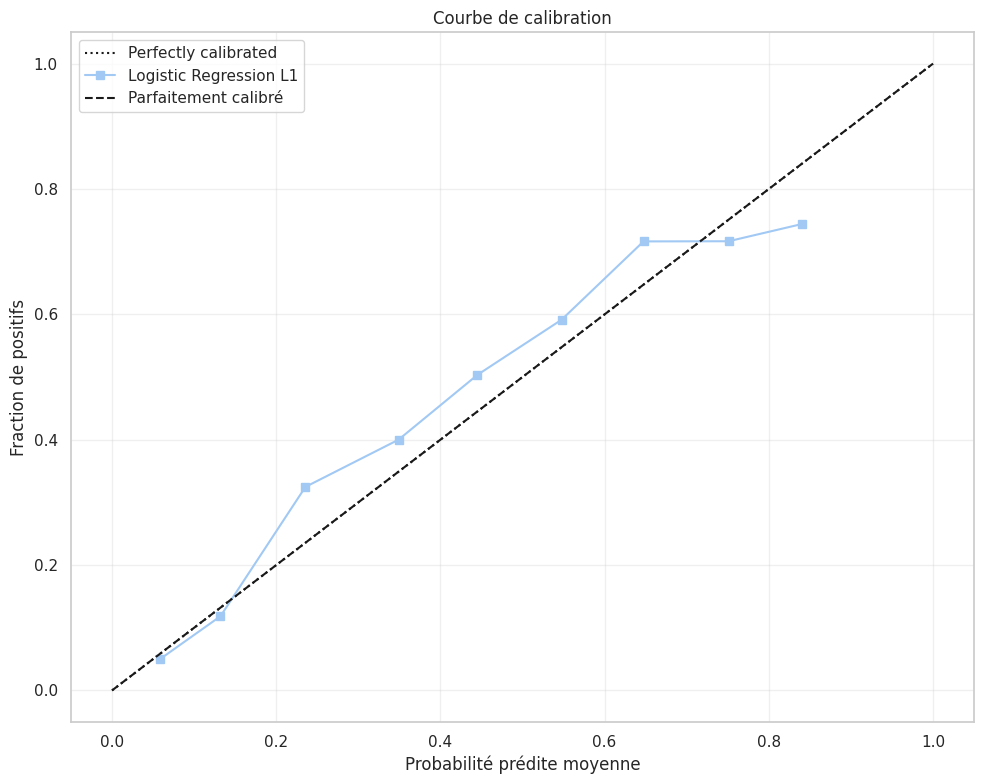

In [61]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

# Prédire les probabilités
y_proba = model_l1.predict_proba(X_test_normalized)[:, 1]

# Créer la courbe de calibration
fig, ax = plt.subplots(figsize=(10, 8))

CalibrationDisplay.from_predictions(
    y_test, 
    y_proba,
    n_bins=10,
    strategy='uniform',  # ou 'quantile'
    ax=ax,
    name='Logistic Regression L1'
)

plt.plot([0, 1], [0, 1], 'k--', label='Parfaitement calibré')
plt.title('Courbe de calibration')
plt.xlabel('Probabilité prédite moyenne')
plt.ylabel('Fraction de positifs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()